In [1]:
import pandas as pd
import tensorflow as tf
import os
from working_data import clean_cols, clean_non_minute_rows, label_df, normalize_by_window, split_df
from data_builder import create_dataset_generator, get_total_rows
from model_builder import build_combined_model, combined_loss
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2024-10-13 19:23:14.999941: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-13 19:23:15.582098: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-13 19:23:16.693047: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-13 19:23:18.606880: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-13 19:23:18.800966: 

In [2]:
NORMALIZING_WINDOW_SIZE = 180
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.4
LABEL_CUR_CANDLE_MULTIPLIER = 4
LABEL_MEAN_MULTIPLIER = 2
BATCH_SIZE = 32
NUM_TRANSFORMER_TOKENS = 120
NUM_CNN_TOKENS = 4
D_MODEL = 64
FF_DIM = 256
NUM_HEADS = 4
NUM_TRANSFORMER_LAYERS = 2

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
# df = pd.read_csv(source_csv)
# df = clean_non_minute_rows(df)
# break_point = len(df) - len(df)//5
# df = df[break_point:]
# df = clean_cols(df) 
# df = normalize_by_window(df, window_size=NORMALIZING_WINDOW_SIZE)
# df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
# split_df(df=df, dump_path=working_path)

In [5]:
transformer_input_shape = (NUM_TRANSFORMER_TOKENS, 4)
cnn_input_shape = (NUM_CNN_TOKENS, 4, 1)
model = build_combined_model(transformer_input_shape, cnn_input_shape, d_model=D_MODEL, ff_dim=FF_DIM, num_heads=NUM_HEADS, num_layers=NUM_TRANSFORMER_LAYERS)
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy',auc, prec])

In [6]:
train_file = os.path.join(working_path, 'train.csv')
val_file = os.path.join(working_path, 'val.csv')
test_file = os.path.join(working_path, 'test.csv')

train_dataset= create_dataset_generator(train_file, batch_size=BATCH_SIZE, num_transformer_tokens=NUM_TRANSFORMER_TOKENS, num_cnn_tokens=NUM_CNN_TOKENS, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator(val_file, batch_size=BATCH_SIZE, num_transformer_tokens=NUM_TRANSFORMER_TOKENS, num_cnn_tokens=NUM_CNN_TOKENS, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator(test_file, batch_size=BATCH_SIZE, num_transformer_tokens=NUM_TRANSFORMER_TOKENS, num_cnn_tokens=NUM_CNN_TOKENS).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file)//BATCH_SIZE


In [7]:
class_weight = {
    0:1,
    1:7
}
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_comb_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=10,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    class_weight=class_weight,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_comb_model.keras')

Epoch 1/10


I0000 00:00:1728840206.771088    1479 service.cc:145] XLA service 0x7efed8002690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728840206.771135    1479 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-13 19:23:28.680297: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-13 19:23:30.058806: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1728840219.636012    1619 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_17', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1728840221.254978    1610 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_15', 96 bytes spill stores, 96 bytes spill loads



     1/196492 ━━━━━━━━━━━━━━━━━━━━ 2147:36:03 39s/step - accuracy: 0.2188 - auc: 0.6437 - loss: 1.5974 - precision_1: 0.1071

I0000 00:00:1728840240.147772    1479 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 30084/196492 ━━━━━━━━━━━━━━━━━━━━ 5:33:53 120ms/step - accuracy: 0.7791 - auc: 0.5142 - loss: 1.7597 - precision_1: 0.1204

In [ ]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


8420/8420 ━━━━━━━━━━━━━━━━━━━━ 191s 23ms/step


2024-10-12 20:53:30.882270: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Predict the classes for the test dataset
y_true = []
y_pred = []

for input_tensor, target_tensor in test_dataset:
#     predictions = model.predict(input_tensor)
#     predicted_classes = np.argmax(predictions, axis=1)  # Get the class with the highest score
    y_true.extend(target_tensor.numpy()) 

2024-10-12 20:56:44.463015: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
len(predicted_class), len(y_true)

(269412, 269412)

Confusion Matrix:
 [[201005  33367]
 [  1423  33617]]


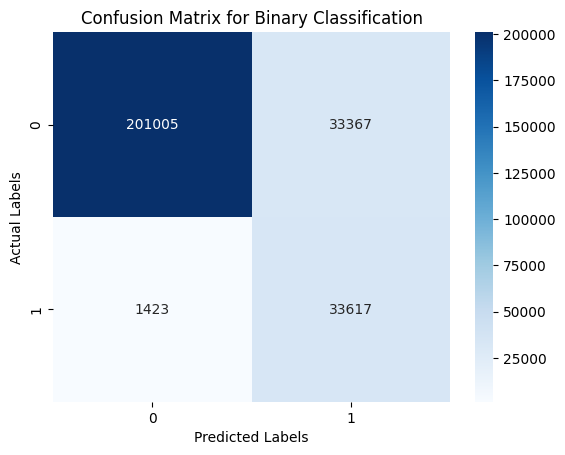

In [ ]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [ ]:
model.evaluate(test_dataset)

   1435/Unknown 43s 30ms/step - accuracy: 0.8735 - auc: 0.9468 - loss: 0.6022 - precision_1: 0.4832